In [3]:
import torch
import torch.nn as nn
import time
import pickle 
import numpy as np
from pathlib import Path
from datetime import datetime
from model3 import Generator
from utils import cal_passing_rate, cal_epoch_rate
from utils import plot_slice, plot_data, cal_delta
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import itertools

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import torch.nn.functional as F
import pandas as pd
# To check the neighboring voxels
def plot_data_matrix(batch_data, batch_fake, data_name, save_folder_path, epoch=1):
    
    voxel = np.arange(256)
    voxel_size = 0.666016*2
    x_vals = (voxel * voxel_size - 170.5)

    # Define the mm values for the ticks within the range of x_vals
    min_x, max_x = min(x_vals), max(x_vals)
    tick_mm_values = np.arange(-150, 150, 25)
    tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

    print('batch size:', len(batch_data))
    for i in range(len(batch_data)):
        fig = plt.figure(figsize=(15, 15))  # Adjust figure size for 9 subplots
        gs = gridspec.GridSpec(3, 3)  # 3 rows, 3 columns

        real_dose = batch_data[i].squeeze().cpu().numpy()
        fake_dose = batch_fake[i].squeeze().cpu().numpy()
        max_index = np.unravel_index(real_dose.argmax(), real_dose.shape)

        # Indices for slices
        slice_adjust = [-1, 0, 1]

        # Loop over all combinations of indices
        for j, (dx, dy) in enumerate(itertools.product(slice_adjust, repeat=2)):
            ax = plt.subplot(gs[j])

            # Calculate slice indices
            slice_x = max_index[0] + dx
            slice_y = max_index[1] + dy

            # Extract slices
            real_dose_slice = real_dose[slice_x, slice_y, :]
            fake_dose_slice = fake_dose[slice_x, slice_y, :]

            # Plot real and fake data
            ax.plot(x_vals, real_dose_slice, label='Simulated')
            ax.plot(x_vals, fake_dose_slice, label='Generated', linestyle='--')
            ax.set_ylabel('Dose/Dose_max')
            ax.set_ylim(0,1.0)
            ax.set_xlabel('Depth [mm]')
            ax.set_xticks(tick_mm_values)
            ax.set_xticklabels([f"{mm:.0f}" for mm in tick_mm_values])
            ax.set_title(f'{data_name[i]} - Slice {slice_x+1}, {slice_y+1}')
            ax.legend(loc='upper right')

        plt.suptitle('Comparison of Simulated and Generated Data Dose Along the Beam')
        individual_save_filename = f'epoch{epoch}_{data_name[i][:-4]}.png'
        plt.savefig(os.path.join(save_folder_path, individual_save_filename))
        plt.close(fig)


def test_model(model_g_path, device, test_subset, test_dir):
    
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=8)
    model = Generator()
    # Load the model
    #if device == 'cpu':
    if torch.cuda.is_available() == False:
        state_dict = torch.load(model_g_path, map_location=torch.device('cpu')) # to edit when use gpu
        model.load_state_dict(state_dict)
    else:
        model = model.to(device)
        state_dict = torch.load(model_g_path)
        model.load_state_dict(state_dict)

    model.eval()

    total_mse_loss = 0

    total_delta = 0
    total_samples = 0
    startTime = time.time()
    passing_rates1 =[]
    passing_rates3 =[]
    total_mse_loss_none =[]
    # Initialize an empty list to store results
    results_data = []
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop over the validation set
        for batch_idx, (real,cond, water_tensor, density_tensor, data_name) in enumerate(test_loader): 
            #if batch_idx ==0:
                cur_batch_size = real.shape[0]    
                # print(f"Processing val batch {batch_idx}")
                # send the input to the device
                real = real.to(device)
                cond = cond.to(device)     
                # Forward pass
                fake = model(cond).float().to(device)

                # Calculate average MSE per voxel for each position (y, z) 
                mse_values = torch.mean((fake - real)**2, dim=(2, 3,4)).cpu().numpy() # number = Batch size
                # Extract y, z positions from data_name
                for i in range(cur_batch_size):
                    print(data_name[i])
                    dataset , energy, y_position, z_position = data_name[i].split("_")
                    print(data_name[i])
                    dataset = str(dataset)
                    energy =  float(energy[:-3])
                    y_position = float(y_position[:-2])  # Remove "Mm" and convert to float
                    z_position = float(z_position[:-6])  # Remove "Mm" and convert to float
                    # Flatten the MSE values and append to the results_data list
                    # Flatten the MSE values and add to the list       
                    results_data.append({"dataset": dataset, "y_position": y_position, "z_position": z_position, "energy": energy, "mse_value": np.mean(mse_values[i])})
                    
    # Create a DataFrame from the list of data
    results_df = pd.DataFrame(results_data)
    
    return results_df


In [12]:
import torch
import torch.nn as nn
import time
import pickle 
import numpy as np
from pathlib import Path
from datetime import datetime
from model3 import Generator
from utils import cal_passing_rate, cal_epoch_rate
from utils import plot_slice, plot_data, cal_delta
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import itertools

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import torch.nn.functional as F
import pandas as pd
if __name__ == "__main__":
    # Define or load model_g_path, device, test_loader, test_dir
    model_g_path = "/home/tappay01/test/runs/25012241_LRG_0.003_LRC_8e-06_L_10_opt_RMSprop/generator.pth"
    #"/home/tappay01/test/runs/20012319_LRG_0.003_LRC_3e-05_L_10_opt_RMSprop/MSE_0.9230388497707734_generator_epoch943.pth"
    #"/home/tappay01/test/runs/06011537_LRG_0.003_LRC_1e-05_L_10_CI_5_opt_Adam/MSE_0.9014486875289526_generator_epoch1807.pth"
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(device)

    saved_test_dataset = "/home/tappay01/new_data/16011153/test_dataset.pkl"
    with open(saved_test_dataset, 'rb') as file:
        test_subset = pickle.load(file)
    print('Number of test samples :', len(test_subset))
    
    # Create target directory
    log_dir = "/home/tappay01/test/runs/28012024"
    test_dir = Path(log_dir)
    test_dir.mkdir(parents=True, exist_ok=True)

    results_df = test_model(model_g_path, device , test_subset, test_dir)
# Write the DataFrame to a CSV file
#results_df.to_csv("mse_results_test_dataset.csv", index=False)

cpu
Number of test samples : 240


Data5_2500MeV_0Mm_-46.5Mm.npy
Data5_2500MeV_0Mm_-46.5Mm.npy
Data7_2125MeV_25Mm_-46.5Mm.npy
Data7_2125MeV_25Mm_-46.5Mm.npy
Data2_2375MeV_25Mm_-146.5Mm.npy
Data2_2375MeV_25Mm_-146.5Mm.npy
Data7_2250MeV_-25Mm_-96.5Mm.npy
Data7_2250MeV_-25Mm_-96.5Mm.npy
Data5_2375MeV_25Mm_-21.5Mm.npy
Data5_2375MeV_25Mm_-21.5Mm.npy
Data1_1875MeV_50Mm_-121.5Mm.npy
Data1_1875MeV_50Mm_-121.5Mm.npy
Data5_1875MeV_-50Mm_-46.5Mm.npy
Data5_1875MeV_-50Mm_-46.5Mm.npy
Data7_1500MeV_-25Mm_-46.5Mm.npy
Data7_1500MeV_-25Mm_-46.5Mm.npy
Data2_1875MeV_75Mm_-146.5Mm.npy
Data2_1875MeV_75Mm_-146.5Mm.npy
Data1_2250MeV_50Mm_-121.5Mm.npy
Data1_2250MeV_50Mm_-121.5Mm.npy
Data1_2000MeV_-50Mm_-46.5Mm.npy
Data1_2000MeV_-50Mm_-46.5Mm.npy
Data1_1750MeV_25Mm_-121.5Mm.npy
Data1_1750MeV_25Mm_-121.5Mm.npy
Data5_2125MeV_0Mm_-46.5Mm.npy
Data5_2125MeV_0Mm_-46.5Mm.npy
Data2_2500MeV_50Mm_-71.5Mm.npy
Data2_2500MeV_50Mm_-71.5Mm.npy
Data2_1500MeV_0Mm_-71.5Mm.npy
Data2_1500MeV_0Mm_-71.5Mm.npy
Data7_1875MeV_75Mm_-96.5Mm.npy
Data7_1875MeV_75Mm_-96.5Mm.

In [5]:
print(results_df.describe())
print(results_df.head())

       y_position  z_position       energy   mse_value
count  300.000000  300.000000   300.000000  300.000000
mean    12.500000  -46.500000  2125.000000    0.001070
std     27.997551   35.414412   540.964084    0.000853
min    -25.000000  -96.500000  1250.000000    0.000007
25%     -6.250000  -71.500000  1625.000000    0.000364
50%     12.500000  -46.500000  2125.000000    0.000824
75%     31.250000  -21.500000  2625.000000    0.001602
max     50.000000    3.500000  3000.000000    0.003350
  dataset  y_position  z_position  energy  mse_value
0   Data8       -25.0       -21.5  2875.0   0.002699
1   Data8       -25.0       -46.5  1750.0   0.001116
2   Data8         0.0         3.5  1625.0   0.000027
3   Data8       -25.0       -71.5  1625.0   0.001077
4   Data8       -25.0       -71.5  2625.0   0.002730


density.shape  (135, 256, 256)
y_vals  -186.0 185.99974400000002
z_vals  -186.25 151.25


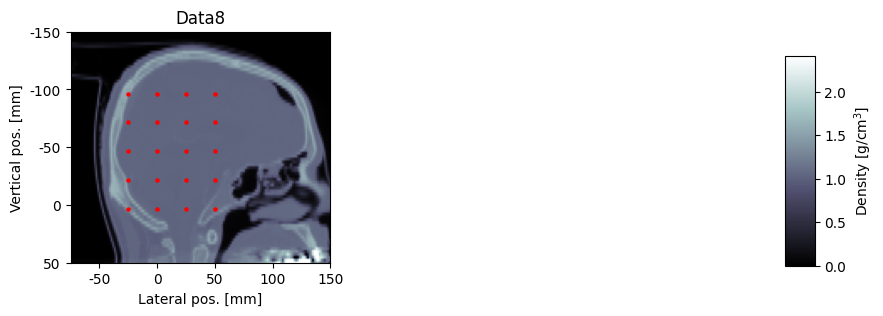

In [6]:
# xzy
datasets = {
    "Data1": {
        "voxel_dim": [0.707031*2, 0.707031*2, 1.25*2],
        "origin": [-181, -181, -229],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-146.5, -121.5, -96.5, -71.5, -46.5],
        "voxel_center": [0,0,-71.5]
    },
    "Data2": {
        "voxel_dim": [0.759766*2, 0.759766*2, 1.25*2],
        "origin": [-194.5, -194.5, -271],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-171.5, -146.5, -121.5, -96.5, -71.5], # exclude -171.5
        "voxel_center": [0,0,-72.25]
    },
    "Data4": {
        "voxel_dim": [0.666016*2, 0.666016*2, 1.25*2],
        "origin": [-170.5,-170.5, -188.75],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-32.5]
    },
    "Data5": {
        "voxel_dim": [0.689453*2, 0.689453*2, 1.25*2],
        "origin": [-176.5, -176.5, -208.25],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-44.5]
    },
    "Data7": {
        "voxel_dim": [0.683594*2, 0.683594*2, 1.25*2],
        "origin": [-175, -175, -199.25],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-29.25]
    },
    "Data8": {
        "voxel_dim": [0.726562*2, 0.726562*2, 1.25*2],
        "origin": [-186, -186, -186.25],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50],
        "positions_z": [-96.5, -71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-16.25]
    }
}
Data = "Data8"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset8/densities.npy"

density = np.load(density_path)
print("density.shape ",density.shape) # zyx (124, 256, 256) 

voxel_size = datasets[Data]["voxel_dim"] # Example voxel sizes in mm for each dimension
origin = datasets[Data]["origin"]  # Example origin in mm for each dimension

# Coordinates for the red points
lateral_positions = datasets[Data]["positions_y"] #[-50, -25, 0, 25, 50, 75]
vertical_positions = datasets[Data]["positions_z"] #[-71.5, -46.5, -21.5, 3.5]

# Calculate the x and z values in millimeters
voxel = np.arange(density.shape[2]+1) 
x_vals = (voxel * voxel_size[0] + origin[0])
yvoxel = np.arange(density.shape[1]+1)
y_vals = (yvoxel * voxel_size[1] + origin[1])
zvoxel = np.arange(density.shape[0]+1)
z_vals = (zvoxel * voxel_size[2] + origin[2])
print("y_vals ",min(y_vals), max(y_vals))
print("z_vals ",min(z_vals), max(z_vals))
x_extent = [-origin[0], origin[0]] #-X_MIN,X_MIN
y_extent = [origin[1], -origin[1]] #Y_MIN,-Y_MIN
z_extent = [ max(z_vals) ,min(z_vals)] #86,Z_MIN
# Define the mm values for the ticks within the range of x_vals and z_vals
tick_mm_values = np.arange(np.floor(min(x_vals)), np.ceil(max(x_vals)) + 1, 25)  # in mm
ytick_mm_values = np.arange(np.floor(min(y_vals)), np.ceil(max(y_vals)) + 1, 25)  # in mm
ztick_mm_values = np.arange(np.floor(min(z_vals)), np.ceil(max(z_vals)) + 1, 25)  # in mm

# Define the mm values for the ticks within the range of x_vals
min_x, max_x = min(x_vals), max(x_vals)
tick_mm_values = np.arange(-150, 175, 50)  # Adjust the start and end according to your needs
tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

min_y, max_y = min(y_vals), max(y_vals)
ytick_mm_values = np.arange(-200, 200, 50)  # Adjust the start and end according to your needs
ytick_mm_values = ytick_mm_values[(ytick_mm_values >= min_y) & (ytick_mm_values <= max_y)]

min_z, max_z = min(z_vals), max(z_vals)
ztick_mm_values = np.arange(-250, 150, 50)  # Adjust the start and end according to your needs
ztick_mm_values = ztick_mm_values[(ztick_mm_values >= min_z) & (ztick_mm_values <= max_z)]



# Identify the slice with the maximum density value
max_index = [50,128,120]


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Assuming you have 2 subplots in 1 row
gs = GridSpec(1, 2, width_ratios=[1, 0.05])  # Adjust the width_ratios as needed

# Create figure and grid specification
fig = plt.figure(figsize=(15, 3))

# ZY plane
colormap = 'bone'
ax0 = plt.subplot(gs[0])
zy_slice = density[:, :, max_index[2]]
cax0 = ax0.imshow(zy_slice, cmap=colormap, extent=y_extent + z_extent)
ax0.set_xlabel('Lateral pos. [mm]')
ax0.set_ylabel('Vertical pos. [mm]')
ax0.set_xticks(ytick_mm_values)
ax0.set_yticks(ztick_mm_values)
ax0.set_xticklabels(ytick_mm_values.astype(int))
ax0.set_yticklabels(ztick_mm_values.astype(int))

# Limit the visible range on x and y axes
ax0.set_xlim([-75, 150])  # Replace xmin and xmax with your desired limits
ax0.set_ylim([50, -150])  # Replace ymin and ymax with your desired limits


# Add red points to the ZY plane plot
for y in lateral_positions:
    for z in vertical_positions:
        ax0.scatter(y, z, color='red', s=5)  # s is the size of the point

plt.title(str(Data))

# Colorbar
cbar_ax = fig.add_axes([0.85, 0.1, 0.02, 0.7])  # Adjust the third value for width

# Create colorbar in the custom axes
cbar = plt.colorbar(cax0, cax=cbar_ax)
cbar.set_label(r'Density [g/cm$^3$]')

plt.show()



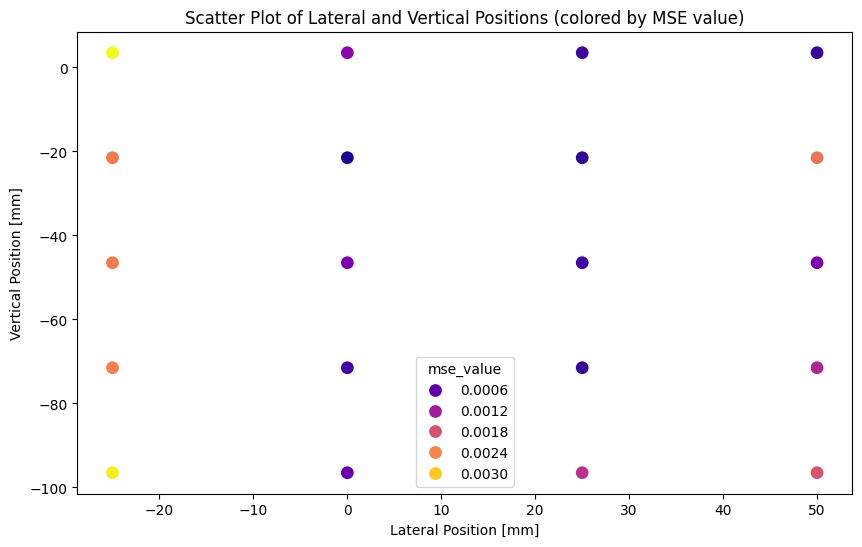

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns



# Scatter plot of 'y_position' and 'z_position'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='y_position', y='z_position', data=results_df, hue='mse_value', palette='plasma',s=100)
plt.title('Scatter Plot of Lateral and Vertical Positions (colored by MSE value)')
plt.xlabel('Lateral Position [mm]')
plt.ylabel('Vertical Position [mm]')
plt.show()

density.shape  (126, 256, 256)

y_vals  -181.0 180.99987199999998
z_vals  -229.0 86.0


/tmp/ipykernel_26923/636538299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


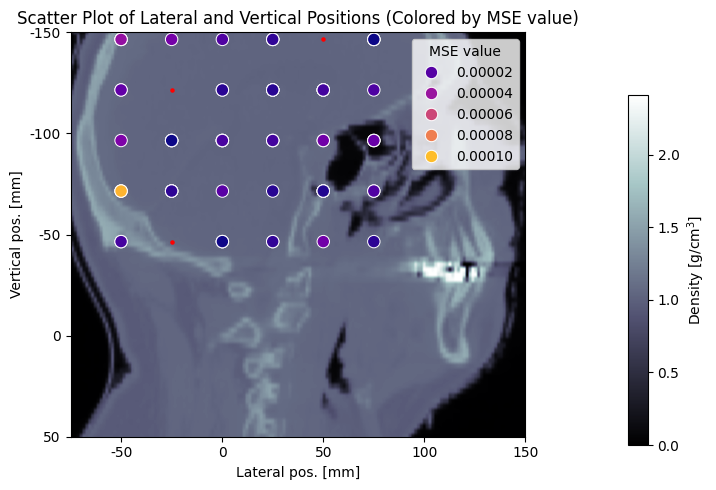

density.shape  (158, 256, 256)

y_vals  -194.5 194.50019200000003
z_vals  -271.0 124.0


/tmp/ipykernel_26923/636538299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


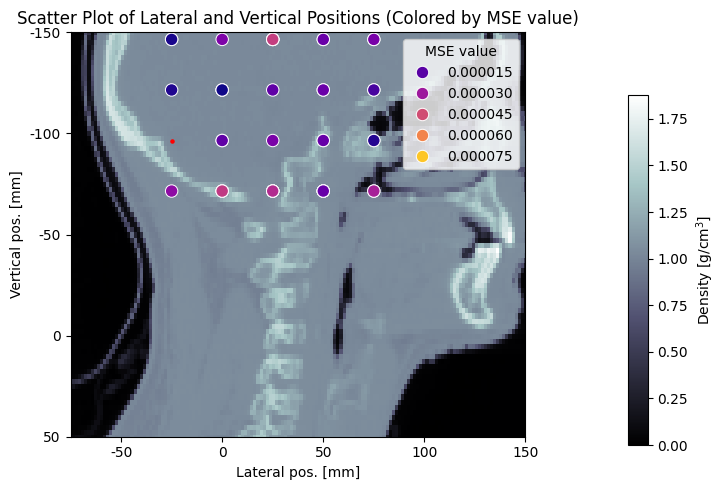

density.shape  (124, 256, 256)

y_vals  -170.5 170.50019200000003
z_vals  -188.75 121.25


/tmp/ipykernel_26923/636538299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


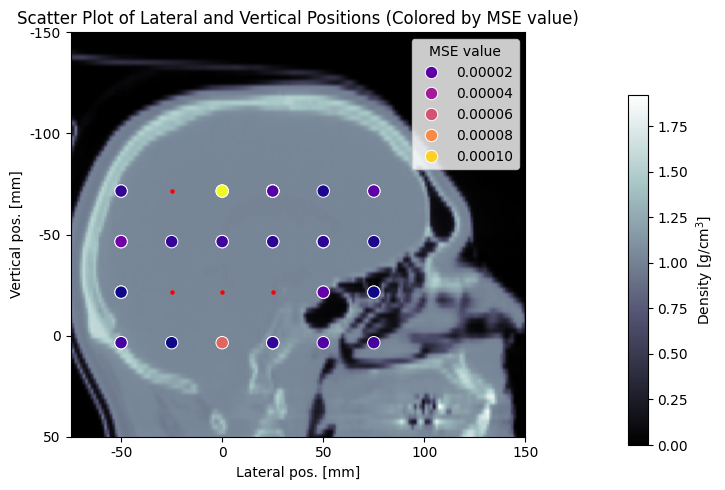

density.shape  (130, 256, 256)

y_vals  -176.5 176.499936
z_vals  -208.25 116.75


/tmp/ipykernel_26923/636538299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


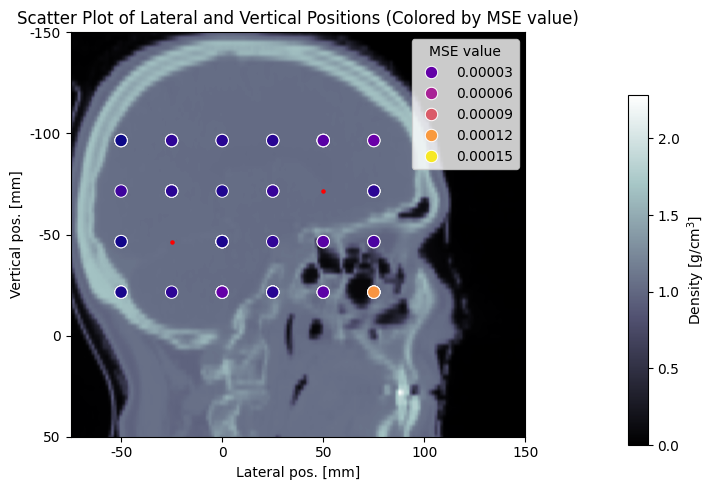

density.shape  (135, 256, 256)

y_vals  -175.0 175.00012800000002
z_vals  -199.25 138.25


/tmp/ipykernel_26923/636538299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


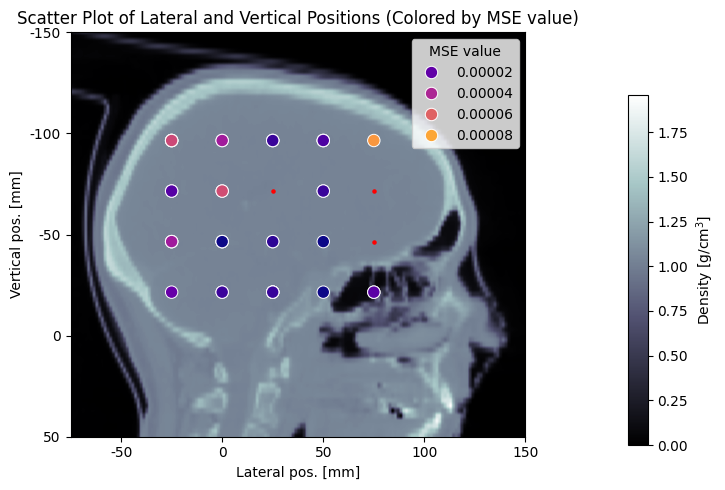

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Specify the dataset you want to filter
target_dataset_list = ['Data1','Data2','Data4','Data5','Data7']
for target_dataset in target_dataset_list:
    # Filter the DataFrame based on the 'dataset' column
    filtered_df = results_df[results_df['dataset'] == target_dataset]

    density_path = "/home/tappay01/new_data/densities/{}.npy".format(target_dataset)
    density = np.load(density_path)
    print("density.shape ",density.shape) # zyx (124, 256, 256) 

    voxel_size = datasets[target_dataset]["voxel_dim"] # Example voxel sizes in mm for each dimension
    origin = datasets[target_dataset]["origin"]  # Example origin in mm for each dimension

    # Coordinates for the red points
    lateral_positions = datasets[target_dataset]["positions_y"] #[-50, -25, 0, 25, 50, 75]
    print()
    vertical_positions = datasets[target_dataset]["positions_z"] #[-71.5, -46.5, -21.5, 3.5]

    # Calculate the x and z values in millimeters
    voxel = np.arange(density.shape[2]+1) 
    x_vals = (voxel * voxel_size[0] + origin[0])
    yvoxel = np.arange(density.shape[1]+1)
    y_vals = (yvoxel * voxel_size[1] + origin[1])
    zvoxel = np.arange(density.shape[0]+1)
    z_vals = (zvoxel * voxel_size[2] + origin[2])
    print("y_vals ",min(y_vals), max(y_vals))
    print("z_vals ",min(z_vals), max(z_vals))
    x_extent = [-origin[0], origin[0]] #-X_MIN,X_MIN
    y_extent = [origin[1], -origin[1]] #Y_MIN,-Y_MIN
    z_extent = [ max(z_vals) ,min(z_vals)] #86,Z_MIN
    # Define the mm values for the ticks within the range of x_vals and z_vals
    tick_mm_values = np.arange(np.floor(min(x_vals)), np.ceil(max(x_vals)) + 1, 25)  # in mm
    ytick_mm_values = np.arange(np.floor(min(y_vals)), np.ceil(max(y_vals)) + 1, 25)  # in mm
    ztick_mm_values = np.arange(np.floor(min(z_vals)), np.ceil(max(z_vals)) + 1, 25)  # in mm

    # Define the mm values for the ticks within the range of x_vals
    min_x, max_x = min(x_vals), max(x_vals)
    tick_mm_values = np.arange(-150, 175, 50)  # Adjust the start and end according to your needs
    tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

    min_y, max_y = min(y_vals), max(y_vals)
    ytick_mm_values = np.arange(-200, 200, 50)  # Adjust the start and end according to your needs
    ytick_mm_values = ytick_mm_values[(ytick_mm_values >= min_y) & (ytick_mm_values <= max_y)]

    min_z, max_z = min(z_vals), max(z_vals)
    ztick_mm_values = np.arange(-250, 150, 50)  # Adjust the start and end according to your needs
    ztick_mm_values = ztick_mm_values[(ztick_mm_values >= min_z) & (ztick_mm_values <= max_z)]



    # Assuming you have 2 subplots in 1 row
    gs = GridSpec(1, 2, width_ratios=[1, 0.05])  # Adjust the width_ratios as needed

    # Create figure and grid specification
    fig = plt.figure(figsize=(10, 5))

    # ZY plane
    colormap = 'bone'
    ax0 = plt.subplot(gs[0])
    zy_slice = density[:, :, max_index[2]]
    cax0 = ax0.imshow(zy_slice, cmap=colormap, extent=y_extent + z_extent)
    ax0.set_xlabel('Lateral pos. [mm]')
    ax0.set_ylabel('Vertical pos. [mm]')
    ax0.set_xticks(ytick_mm_values)
    ax0.set_yticks(ztick_mm_values)
    ax0.set_xticklabels(ytick_mm_values.astype(int))
    ax0.set_yticklabels(ztick_mm_values.astype(int))

    # Limit the visible range on x and y axes
    ax0.set_xlim([-75, 150])  # Replace xmin and xmax with your desired limits
    ax0.set_ylim([50, -150])  # Replace ymin and ymax with your desired limits

    # Add red points to the ZY plane plot
    for y in lateral_positions:
        for z in vertical_positions:
            ax0.scatter(y, z, color='red', s=5)  # s is the size of the point

    # Scatter plot overlay on the same axes (ax0)
    scatter = sns.scatterplot(x='y_position', y='z_position', data=filtered_df, hue='mse_value', palette='plasma', s=80, ax=ax0)

    # Move the legend outside the ax0
    legend = scatter.legend(title='MSE value',bbox_to_anchor=(1, 1), loc='upper right')

    plt.title('Scatter Plot of Lateral and Vertical Positions (Colored by MSE value)')

    # Colorbar
    cbar_ax = fig.add_axes([0.85, 0.1, 0.02, 0.7])  # Adjust the third value for width

    # Create colorbar in the custom axes
    cbar = plt.colorbar(cax0, cax=cbar_ax)
    cbar.set_label(r'Density [g/cm$^3$]')

    plt.tight_layout()
    plt.show()

    '''

    # Scatter plot with different markers for each unique combination of 'y_position' and 'z_position'
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='energy', y='mse_value', data=filtered_df, hue='y_position', style='z_position', palette='tab10', s=70)

    plt.title('Scatter Plot of Energy vs MSE')
    plt.xlabel('Energy [MeV]')
    plt.ylabel('MSE')
    plt.legend(title='position', loc='center left', bbox_to_anchor=(1, 0.5))

    plt.show()
    '''

/tmp/ipykernel_26923/3763758023.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


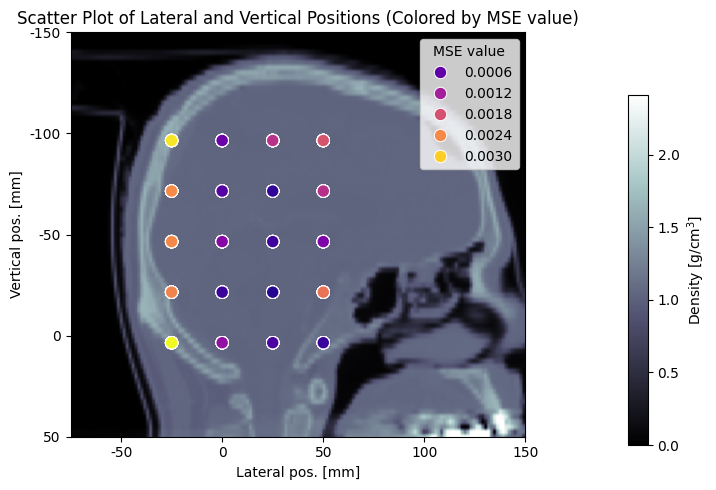

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Assuming you have 2 subplots in 1 row
gs = GridSpec(1, 2, width_ratios=[1, 0.05])  # Adjust the width_ratios as needed

# Create figure and grid specification
fig = plt.figure(figsize=(10, 5))

# ZY plane
colormap = 'bone'
ax0 = plt.subplot(gs[0])
zy_slice = density[:, :, max_index[2]]
cax0 = ax0.imshow(zy_slice, cmap=colormap, extent=y_extent + z_extent)
ax0.set_xlabel('Lateral pos. [mm]')
ax0.set_ylabel('Vertical pos. [mm]')
ax0.set_xticks(ytick_mm_values)
ax0.set_yticks(ztick_mm_values)
ax0.set_xticklabels(ytick_mm_values.astype(int))
ax0.set_yticklabels(ztick_mm_values.astype(int))

# Limit the visible range on x and y axes
ax0.set_xlim([-75, 150])  # Replace xmin and xmax with your desired limits
ax0.set_ylim([50, -150])  # Replace ymin and ymax with your desired limits

# Add red points to the ZY plane plot
for y in lateral_positions:
    for z in vertical_positions:
        ax0.scatter(y, z, color='red', s=5)  # s is the size of the point

# Scatter plot overlay on the same axes (ax0)
scatter = sns.scatterplot(x='y_position', y='z_position', data=results_df, hue='mse_value', palette='plasma', s=80, ax=ax0)

# Move the legend outside the ax0
legend = scatter.legend(title='MSE value',bbox_to_anchor=(1, 1), loc='upper right')

plt.title('Scatter Plot of Lateral and Vertical Positions (Colored by MSE value)')

# Colorbar
cbar_ax = fig.add_axes([0.85, 0.1, 0.02, 0.7])  # Adjust the third value for width

# Create colorbar in the custom axes
cbar = plt.colorbar(cax0, cax=cbar_ax)
cbar.set_label(r'Density [g/cm$^3$]')

plt.tight_layout()
plt.show()


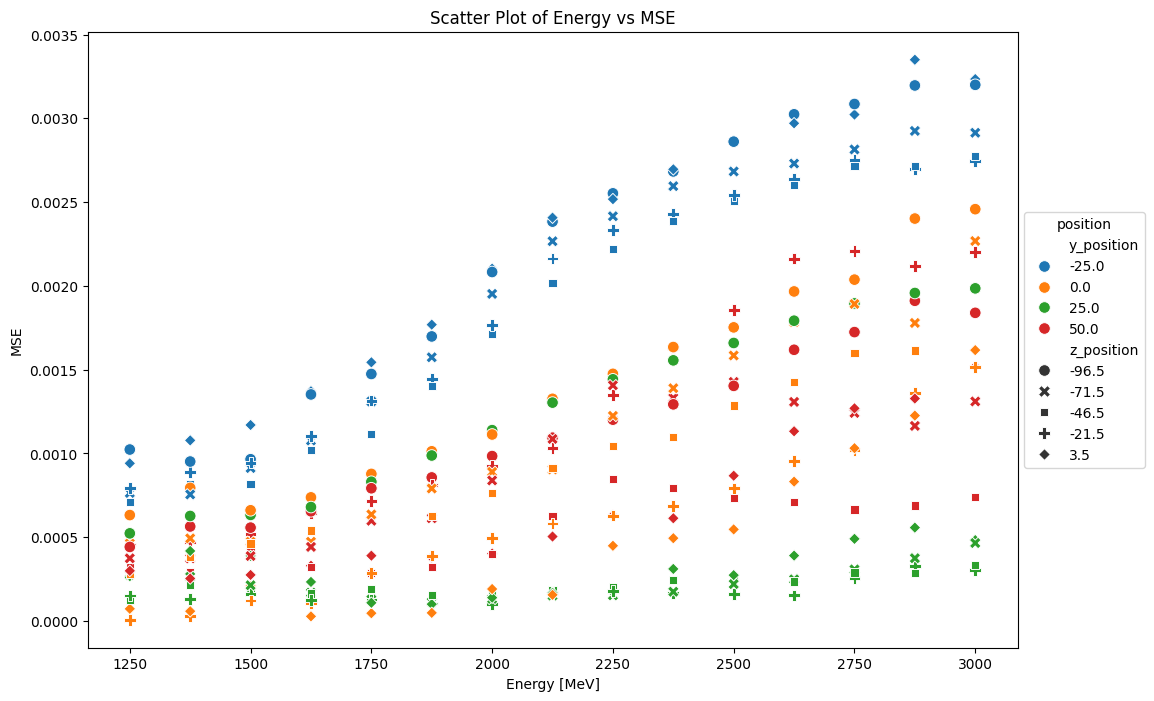

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot with different markers for each unique combination of 'y_position' and 'z_position'
plt.figure(figsize=(12, 8))
sns.scatterplot(x='energy', y='mse_value', data=results_df, hue='y_position', style='z_position', palette='tab10', s=70)

plt.title('Scatter Plot of Energy vs MSE')
plt.xlabel('Energy [MeV]')
plt.ylabel('MSE')
plt.legend(title='position', loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()
